<a href="https://colab.research.google.com/github/danilosnt/CRUD-Flutter/blob/main/Untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
library(dplyr)
library(ggplot2)

dados <- read.csv("datatran2024.csv", sep = ";", fill = TRUE, check.names = FALSE, encoding = "latin1")

print(paste("Total de registros:", nrow(dados)))
head(dados)

[1] "Total de registros: 60365"


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,⋯,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,571789,01/01/2024,segunda-feira,03:56:00,ES,101,38,CONCEICAO DA BARRA,Ultrapassagem Indevida,Colisão lateral sentido oposto,⋯,1,1,1,1,3,"-18,48261","-39,92379",SPRF-ES,DEL04-ES,UOP02-DEL04-ES
2,571804,01/01/2024,segunda-feira,04:50:00,PI,343,185,PIRIPIRI,Manobra de mudança de faixa,Colisão frontal,⋯,0,1,0,0,2,"-4,29603281","-41,76732659",SPRF-PI,DEL02-PI,UOP01-DEL02-PI
3,571806,01/01/2024,segunda-feira,04:30:00,BA,116,578,BREJOES,Ingestão de álcool pelo condutor,Colisão frontal,⋯,0,1,2,0,4,"-13,07158302","-39,9611107",SPRF-BA,DEL03-BA,UOP02-DEL03-BA
4,571818,01/01/2024,segunda-feira,06:30:00,SE,101,18,MALHADA DOS BOIS,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,⋯,1,0,2,1,3,"-10,35601949","-36,90552235",SPRF-SE,DEL02-SE,UOP02-DEL02-SE
5,571838,01/01/2024,segunda-feira,05:00:00,MT,364,240,RONDONOPOLIS,Condutor deixou de manter distância do veículo da frente,Colisão traseira,⋯,0,2,1,0,3,"-16,17914141","-54,78905337",SPRF-MT,DEL02-MT,UOP01-DEL02-MT
6,571855,01/01/2024,segunda-feira,11:50:00,MG,251,447,GRAO MOGOL,Velocidade Incompatível,Colisão traseira,⋯,0,1,1,1,3,"-16,43408996","-43,27992195",SPRF-MG,DEL12-MG,UOP01-DEL12-MG


In [3]:
ranking_uf <- dados %>%
  group_by(uf) %>%
  tally(sort = TRUE)

head(ranking_uf, 1)

uf,n
<chr>,<int>
MG,7597


In [4]:
total <- nrow(dados)
ceu_claro <- nrow(dados %>% filter(condicao_metereologica == "Céu Claro"))

probabilidade <- (ceu_claro / total) * 100
print(paste("A probabilidade é de:", round(probabilidade, 2), "%"))

[1] "A probabilidade é de: 65.16 %"


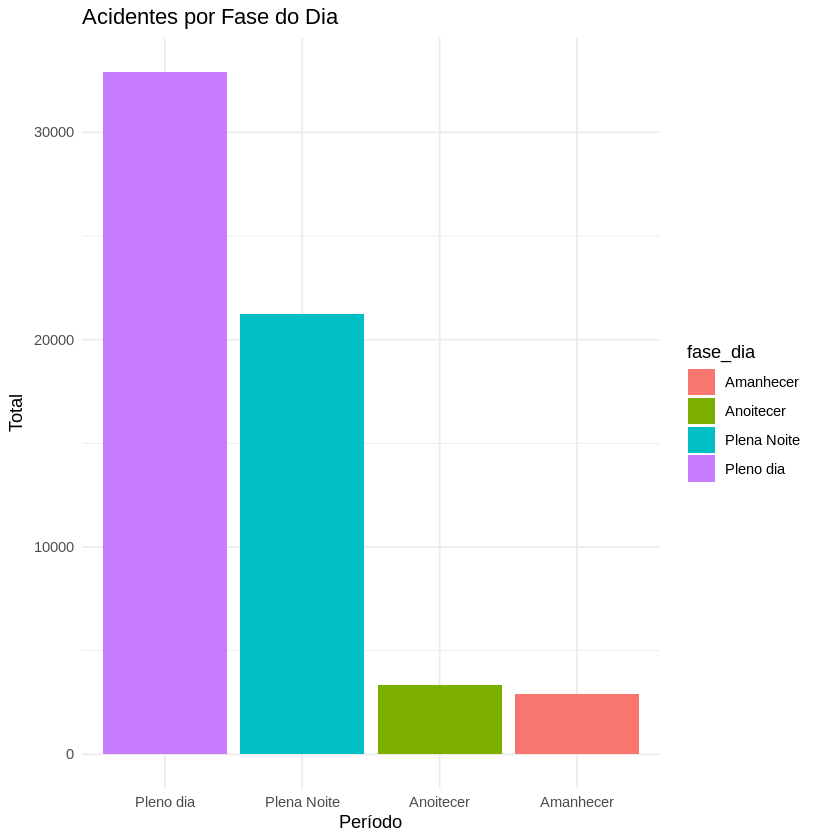

In [5]:
fase_dia_freq <- dados %>%
  group_by(fase_dia) %>%
  tally()

ggplot(fase_dia_freq, aes(x = reorder(fase_dia, -n), y = n, fill = fase_dia)) +
  geom_bar(stat = "identity") +
  theme_minimal() +
  labs(title = "Acidentes por Fase do Dia", x = "Período", y = "Total")

In [6]:
print("Top 5 Tipos de Acidentes:")
print(head(dados %>% group_by(tipo_acidente) %>% tally(sort = TRUE), 5))

print("Top 5 Causas:")
print(head(dados %>% group_by(causa_acidente) %>% tally(sort = TRUE), 5))

[1] "Top 5 Tipos de Acidentes:"
# A tibble: 5 × 2
  tipo_acidente                     n
  <chr>                         <int>
1 Colisão traseira              11638
2 Saída de leito carroçável      8791
3 Colisão transversal            7761
4 Colisão lateral mesmo sentido  6546
5 Tombamento                     5311
[1] "Top 5 Causas:"
# A tibble: 5 × 2
  causa_acidente                                                n
  <chr>                                                     <int>
1 Reação tardia ou ineficiente do condutor                   9000
2 Ausência de reação do condutor                             8804
3 Acessar a via sem observar a presença dos outros veículos  5768
4 Condutor deixou de manter distância do veículo da frente   3731
5 Manobra de mudança de faixa                                3491
